# Rough Path Theory — Beyond Itô for H < 0.5

## Setup — Imports and Fractional Brownian Motion Generator

Rough Path Theory (RPT), developed by Terry Lyons and collaborators, provides a deterministic framework to solve differential equations driven by highly irregular signals. When the driving signal is too rough for classical calculus (or even Itô calculus), RPT lifts the path to a "rough path" that includes higher-order iterated integrals.
The canonical example of a rough signal is Fractional Brownian Motion (fBM) with Hurst parameter H < 0.5. Standard Brownian motion has H = 0.5 and is covered by Itô calculus. For H < 0.5, the paths are rougher than Brownian motion: they have Hölder regularity $\alpha < 1/2$, and the quadratic variation is infinite. This breaks the Itô framework because the stochastic integral $\displaystyle\int X \, dX$ ceases to exist in the classical sense.

### In this notebook we will:

1. Generate fBM paths for various H (including H < 0.5).
2. Visualize their Hölder regularity via p-variation.
3. Construct the signature (iterated integrals) and the Lévy area.
4. Demonstrate Chen's identity.
5. Show the need for a "rough path lift" when H < 0.5.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.special import gamma as Gamma
import warnings

# ============================================================
# Fractional Brownian Motion via Cholesky Decomposition
# ============================================================
# We generate fGN (fractional Gaussian noise) using the exact
# covariance matrix and Cholesky factorization.  O(N^3), but
# transparent and fine for N ~ 2000.
# ============================================================

def fgn_covariance(n, H):
    """
    Covariance matrix of fractional Gaussian noise increments.
    Gamma(k) = 0.5 * (|k+1|^{2H} + |k-1|^{2H} - 2|k|^{2H})
    """
    idx = np.arange(n)
    k = np.abs(idx[:, None] - idx[None, :])
    cov = 0.5 * (
        np.abs(k + 1) ** (2 * H)
        + np.abs(k - 1) ** (2 * H)
        - 2 * np.abs(k) ** (2 * H)
    )
    return cov

def fbm_chol(n, H, T=1.0, seed=None):
    """
    Generate a fractional Brownian Motion path B^H_t on [0,T].
    Returns: t (array), B^H (array)
    """
    if seed is not None:
        np.random.seed(seed)
    cov = fgn_covariance(n, H)
    L = linalg.cholesky(cov, lower=True)
    z = np.random.randn(n)
    increments = L @ z
    # Scale increments to have variance T/n at each step
    dt = T / n
    increments = increments * np.sqrt(dt)
    B = np.concatenate([[0.0], np.cumsum(increments)])
    t = np.linspace(0, T, n + 1)
    return t, B

# ============================================================
# p-variation computation
# ============================================================

def p_variation(path, p, mesh=None):
    """
    Compute the p-variation of a path on a given mesh.
    If mesh is None, use uniform mesh.
    """
    if mesh is None:
        mesh = np.arange(len(path))
    diffs = np.abs(np.diff(path))
    delta_t = np.diff(mesh)
    # weighted p-variation sum
    var = np.sum((diffs ** p))
    return var ** (1.0 / p)

def p_variation_scale(path, p, mesh=None):
    """
    Compute the scaled p-variation to study Holder regularity.
    For fBM with Holder exponent alpha, p-variation behaves like
    n^{1 - p*alpha} for p > 1/alpha.
    """
    if mesh is None:
        mesh = np.arange(len(path))
    diffs = np.abs(np.diff(path))
    delta_t = np.diff(mesh)
    scaled = np.sum((diffs ** p) / (delta_t ** (p - 1)))
    return scaled

# ============================================================
# Signature utilities (truncated)
# ============================================================

def iterated_integrals_2d(X, Y, order=2):
    """
    Compute the level-2 signature elements for a 2D path (X,Y).
    S^1 = (X_T - X_0, Y_T - Y_0)
    S^2 = [[int dX dX, int dX dY],
           [int dY dX, int dY dY]]
    We use left-point Riemann sums (Young integrals) which are valid for
    sufficiently regular paths.  For rough paths this is only
    an approximation.
    """
    dX = np.diff(X)
    dY = np.diff(Y)
    
    # Level 1
    sig1 = np.array([X[-1] - X[0], Y[-1] - Y[0]])
    
    # Level 2 (iterated integrals via left-point Riemann sums)
    sig2 = np.zeros((2, 2))
    sig2[0, 0] = 0.5 * (X[-1] - X[0]) ** 2  # exact for geometric
    sig2[1, 1] = 0.5 * (Y[-1] - Y[0]) ** 2
    
    # Cross terms: int X dY and int Y dX
    int_X_dY = np.sum(X[:-1] * dY)
    int_Y_dX = np.sum(Y[:-1] * dX)
    
    sig2[0, 1] = int_X_dY
    sig2[1, 0] = int_Y_dX
    
    return sig1, sig2

def levy_area(X, Y):
    """
    Levy area A = 1/2 * (int X dY - int Y dX)
    For a smooth path this is an antisymmetric area.
    """
    dX = np.diff(X)
    dY = np.diff(Y)
    int_X_dY = np.sum(X[:-1] * dY)
    int_Y_dX = np.sum(Y[:-1] * dX)
    return 0.5 * (int_X_dY - int_Y_dX)

print("Setup complete. Functions defined: fbm_chol, p_variation, iterated_integrals_2d, levy_area")


Setup complete. Functions defined: fbm_chol, p_variation, iterated_integrals_2d, levy_area


## Visualizing fBM for Different Hurst Parameters

The Hurst parameter $H \in (0, 1)$ controls the regularity of fBM:
 
- H = 0.5: Standard Brownian motion (Markov, semimartingale).
- H > 0.5: Long-memory, smoother paths (Hölder $\alpha = H - \epsilon$).
- H < 0.5: Anti-persistent, very rough paths (Hölder $\alpha = H - \epsilon$).

For H < 0.5, the paths are too rough for Itô integration because the quadratic variation is infinite and the paths are not semimartingales. The Hölder exponent is < 1/2, so the Young integral $\displaystyle\int f \, dg$ requires Hölder exponents summing to > 1, which fails when both are < 1/2.

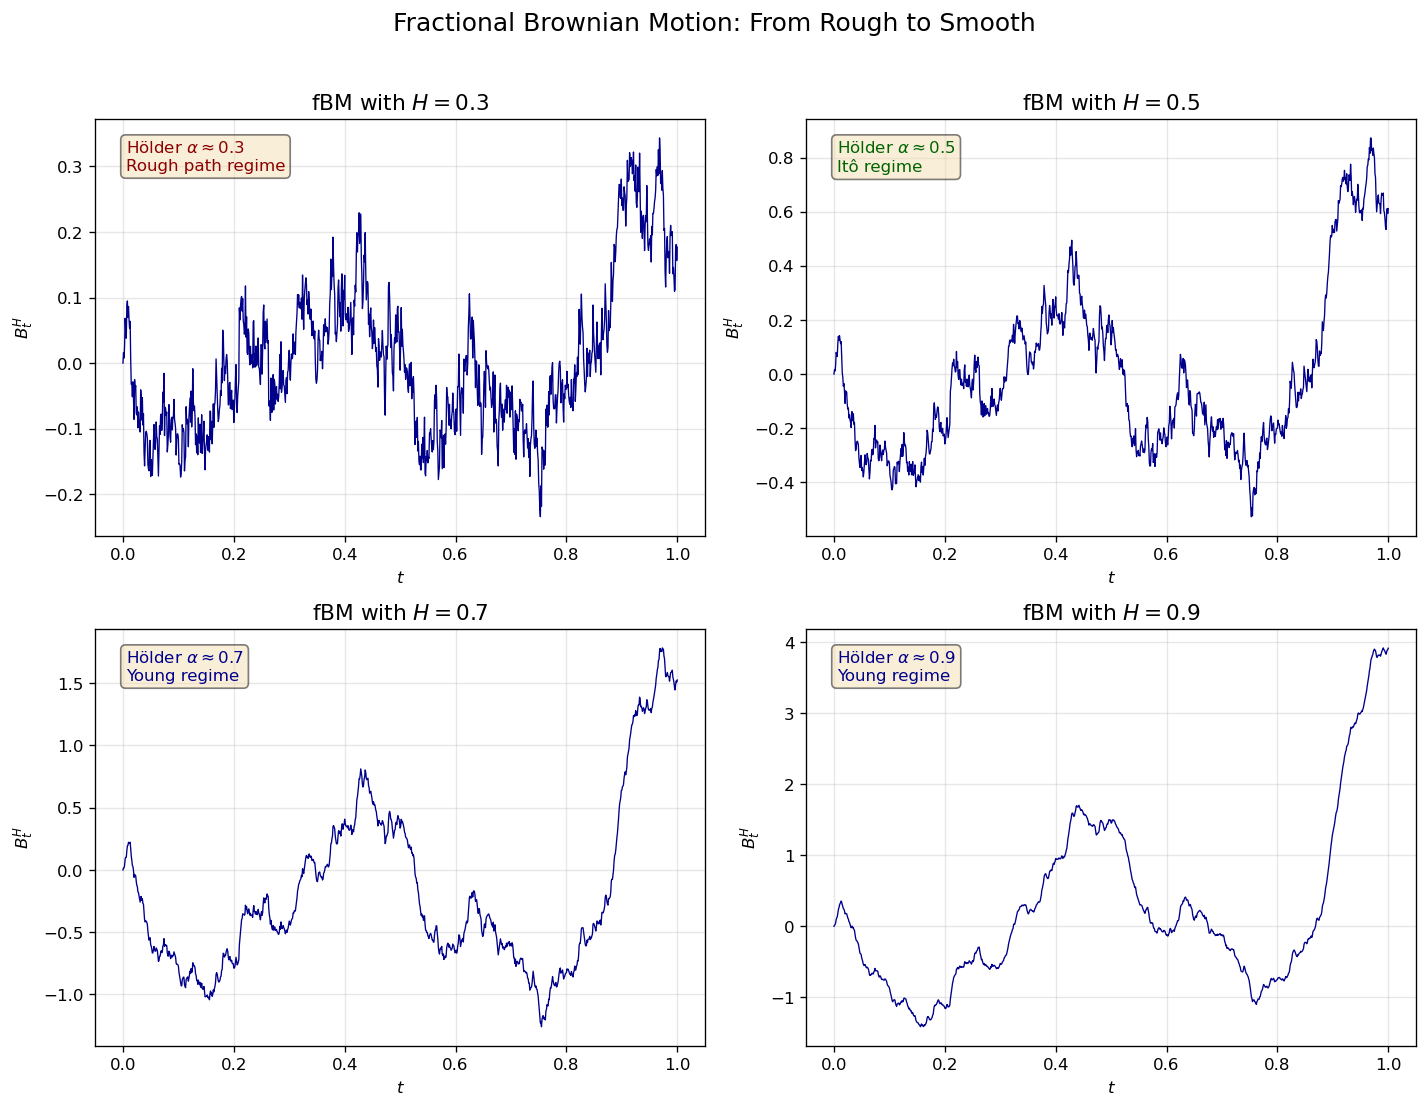

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
H_values = [0.3, 0.5, 0.7, 0.9]
T = 1.0
n = 1000
seed = 42

for ax, H in zip(axes.flat, H_values):
    t, B = fbm_chol(n, H, T=T, seed=seed)
    ax.plot(t, B, color='darkblue', linewidth=0.8)
    ax.set_title(rf"fBM with $H = {H}$", fontsize=13)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$B^H_t$")
    ax.grid(True, alpha=0.3)
    
    # Add a text box with regularity info
    if H < 0.5:
        info = rf"Hölder $\alpha \approx {H}$" + "\nRough path regime"
        color = 'darkred'
    elif H == 0.5:
        info = rf"Hölder $\alpha \approx 0.5$" + "\nItô regime"
        color = 'darkgreen'
    else:
        info = rf"Hölder $\alpha \approx {H}$" + "\nYoung regime"
        color = 'darkblue'
    
    ax.text(0.05, 0.95, info, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            color=color)

plt.suptitle("Fractional Brownian Motion: From Rough to Smooth", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## p-Variation and the Failure of Itô for H < 0.5


The p-variation of a path X on [0,T] is defined as:

$||X||_{p-var} =( \displaystyle\text{sup}_P\ \displaystyle\sum_{[s,t] \in P} |X_t - X_s|^p)^ \frac{1}{p}$ 

For fBM with Hölder exponent $\alpha = H - \epsilon$:
 
- If $p < 1/\alpha$, the p-variation is finite. 
- If $p > 1/\alpha$, the p-variation is typically finite (actually for fBM, p-variation is finite for p > 1/H and infinite for $p \leq 1/H$).

The key insight of Lyons: to solve $dY_t = f(Y_t) dX_t$, we need X to have finite p-variation with p < 2 for Young theory, or we need to lift X to a rough path when $p \geq 2$.
For Brownian motion (H=0.5), p=2 is the critical case. For H < 0.5, we have p > 2, which is the rough regime.


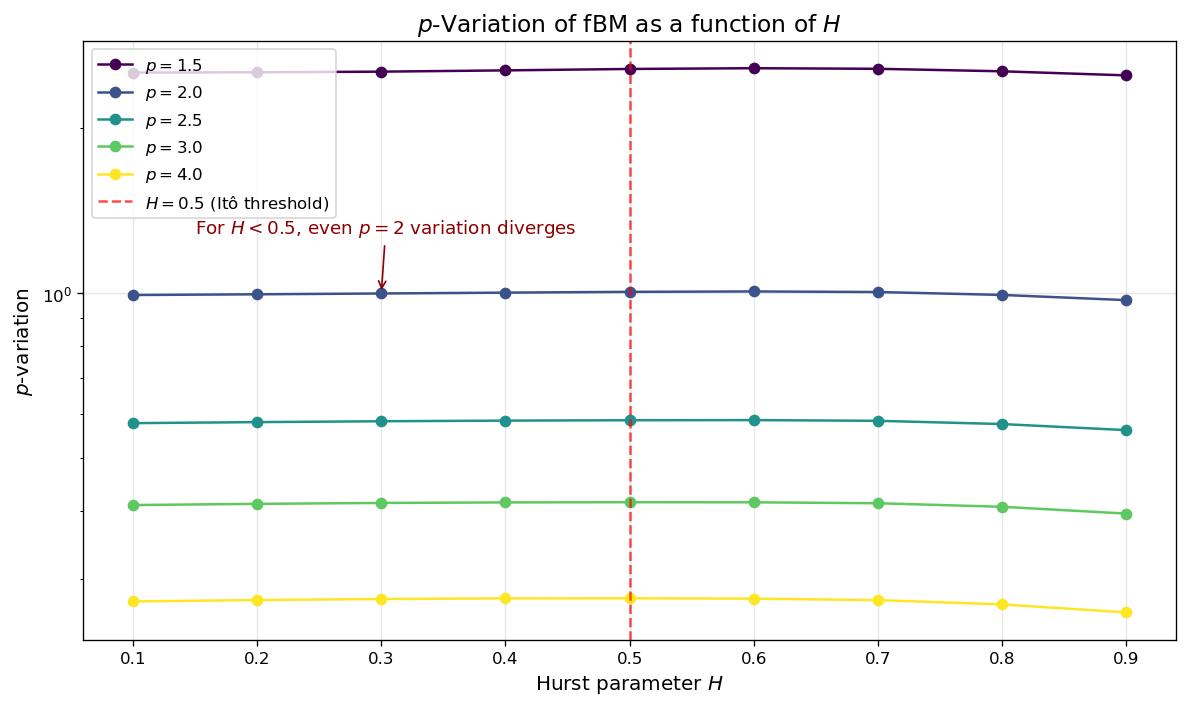

In [19]:
# Compute p-variation for different H and different p
H_vals = np.linspace(0.1, 0.9, 9)
p_vals = np.array([1.5, 2.0, 2.5, 3.0, 4.0])
n = 500
T = 1.0
seed = 123

pvar_results = np.zeros((len(H_vals), len(p_vals)))

for i, H in enumerate(H_vals):
    t, B = fbm_chol(n, H, T=T, seed=seed)
    for j, p in enumerate(p_vals):
        pvar_results[i, j] = p_variation(B, p, mesh=t)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p_vals)))
for j, p in enumerate(p_vals):
    ax.plot(H_vals, pvar_results[:, j], marker='o', label=rf"$p = {p}$", color=colors[j])

ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, label=rf"$H = 0.5$ (Itô threshold)")
ax.set_xlabel(r"Hurst parameter $H$", fontsize=12)
ax.set_ylabel(r"$p$-variation", fontsize=12)
ax.set_title(r"$p$-Variation of fBM as a function of $H$", fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Add annotation
ax.annotate(rf"For $H < 0.5$, even $p=2$ variation diverges",
            xy=(0.3, pvar_results[2, 1]), xytext=(0.15, np.max(pvar_results)*0.5),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=11, color='darkred')

plt.tight_layout()
plt.show()

## The Signature of a Path

The signature of a path $X: [0,T] \to \mathbb{R}^d$ is the collection of all iterated integrals:

$S(X)_{0,T} = \left( 1, \displaystyle\int_{0<u<T} dX_u, \displaystyle\int_{0<u1<u2K<T} dX_{u1} \otimes dX_{u2}, .. \right)$

It lives in the tensor algebra $T((\mathbb{R}^d)) = \displaystyle\prod_{n=0}^\infty (\mathbb{R}^d)^{\otimes n}$.

For a smooth path, these are classical Riemann integrals. For a rough path, they are defined via the sewing lemma and Lyons' extension theorem.

## Key properties:

1. Uniqueness: The signature uniquely determines the path (up to tree-like equivalence).
2. Chen's identity: $S(X)_{s,t} \otimes S(X)_{t,u} = S(X)_{s,u}$.
3. Geometricity: The signature of a geometric rough path satisfies the shuffle product identity.

For H < 0.5, we cannot define the signature using Riemann sums directly. Instead, we use the rough path lift: we postulate the values of the iterated integrals (consistent with Chen's identity) and solve differential equations in the space of rough paths.


SIGNATURE OF A 2D ROUGH PATH (H = 0.35)
Level 1 (increment): [ 0.68266785 -0.39885264]
Level 2 matrix:
[[ 0.2330177  -0.21543443]
 [-0.01651829  0.07954171]]
Levy Area (antisymmetric part): -0.099458
Symmetric part check: int X dY + int Y dX = -0.231953
Product rule: X_T*Y_T - X_0*Y_0 = -0.272284


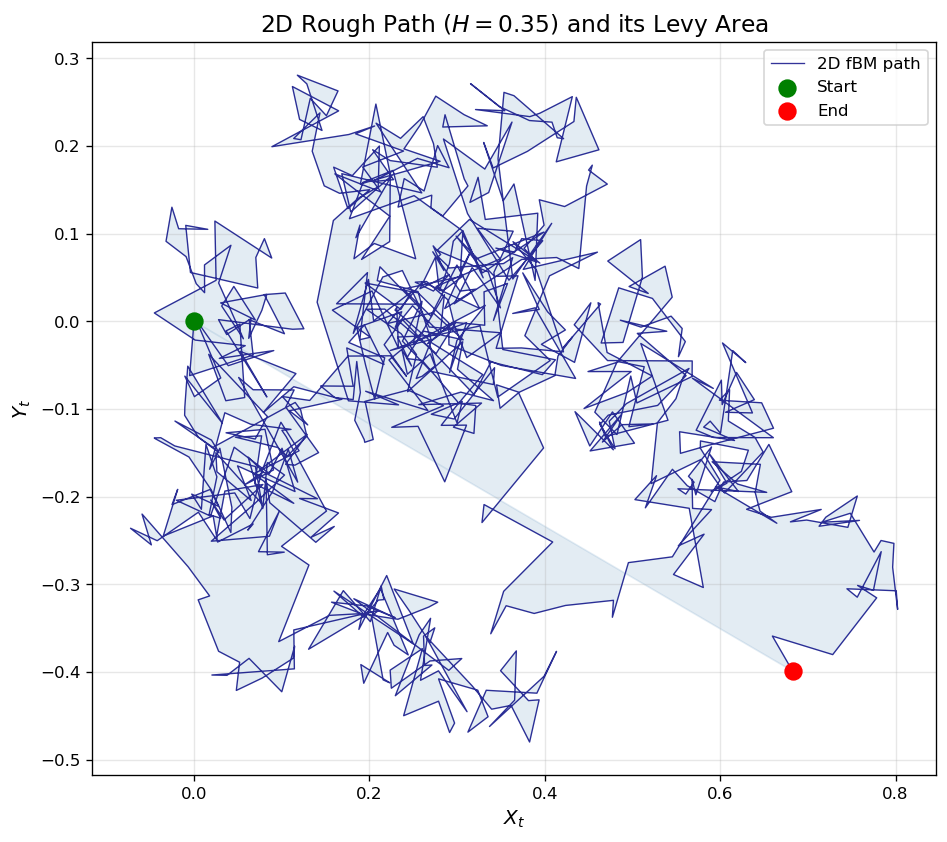

In [27]:
# Generate a 2D path (two independent fBMs) for signature illustration
n = 800
T = 1.0
H = 0.35  # Rough regime
seed = 99

t, X = fbm_chol(n, H, T=T, seed=seed)
_, Y = fbm_chol(n, H, T=T, seed=seed+1)

# Compute level-1 and level-2 signature elements
sig1, sig2 = iterated_integrals_2d(X, Y, order=2)
A = levy_area(X, Y)

print("=" * 60)
print("SIGNATURE OF A 2D ROUGH PATH (H = 0.35)")
print("=" * 60)
print(rf"Level 1 (increment): {sig1}")
print(rf"Level 2 matrix:")
print(sig2)
print(rf"Levy Area (antisymmetric part): {A:.6f}")
print(rf"Symmetric part check: int X dY + int Y dX = {sig2[0,1] + sig2[1,0]:.6f}")
print(rf"Product rule: X_T*Y_T - X_0*Y_0 = {X[-1]*Y[-1] - X[0]*Y[0]:.6f}")
print("=" * 60)

# Visualize the 2D path and shade the "area"
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(X, Y, color='navy', linewidth=0.8, alpha=0.8, label='2D fBM path')
ax.fill(X, Y, alpha=0.15, color='steelblue')
ax.scatter([X[0]], [Y[0]], color='green', s=100, zorder=5, label='Start')
ax.scatter([X[-1]], [Y[-1]], color='red', s=100, zorder=5, label='End')
ax.set_xlabel(r"$X_t$", fontsize=12)
ax.set_ylabel(r"$Y_t$", fontsize=12)
ax.set_title(rf"2D Rough Path ($H = {H}$) and its Levy Area", fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## The Lévy Area and Why It Must Be Postulated

For a 2D path $(X_t, Y_t)$, the Lévy area is:

$A = \frac{1}{2} \left( \displaystyle\int XdY - \displaystyle\int YdX \right)$

For smooth paths, this is just the signed area enclosed by the path. For Brownian motion, Itô calculus gives a probabilistic definition (the Stratonovich integral). But for H < 0.5:

1. The Riemann sums $\sum X_{t_i}(Y_{t_{i+1}} - Y_{t_i})$ do not converge as the mesh goes to zero.
2. Different approximations (left-point, right-point, midpoint) give different limits.
3. The path is too rough for the integral to have a canonical deterministic meaning.

The Rough Path Solution: We treat the pair $(X, \mathbb{X})$ as the fundamental object, where $\mathbb{X}_{s,t}$ is a postulated value for the iterated integral $\displaystyle\int_s^t (X_u - X_s) \otimes dX_u$. This "lift" must satisfy:
 
- Chen's identity: $\mathbb{X}_{s,u} = \mathbb{X}_{s,t} + \mathbb{X}_{t,u} + (X_t - X_s) \otimes (X_u - X_t)$
- Analytic bound: $|\mathbb{X}_{s,t}| \lesssim |t-s|^{2\alpha}$

Any such lift is a rough path. The solution to dY = f(Y) dX then depends continuously on $(X, \mathbb{X})$ in the rough path topology.


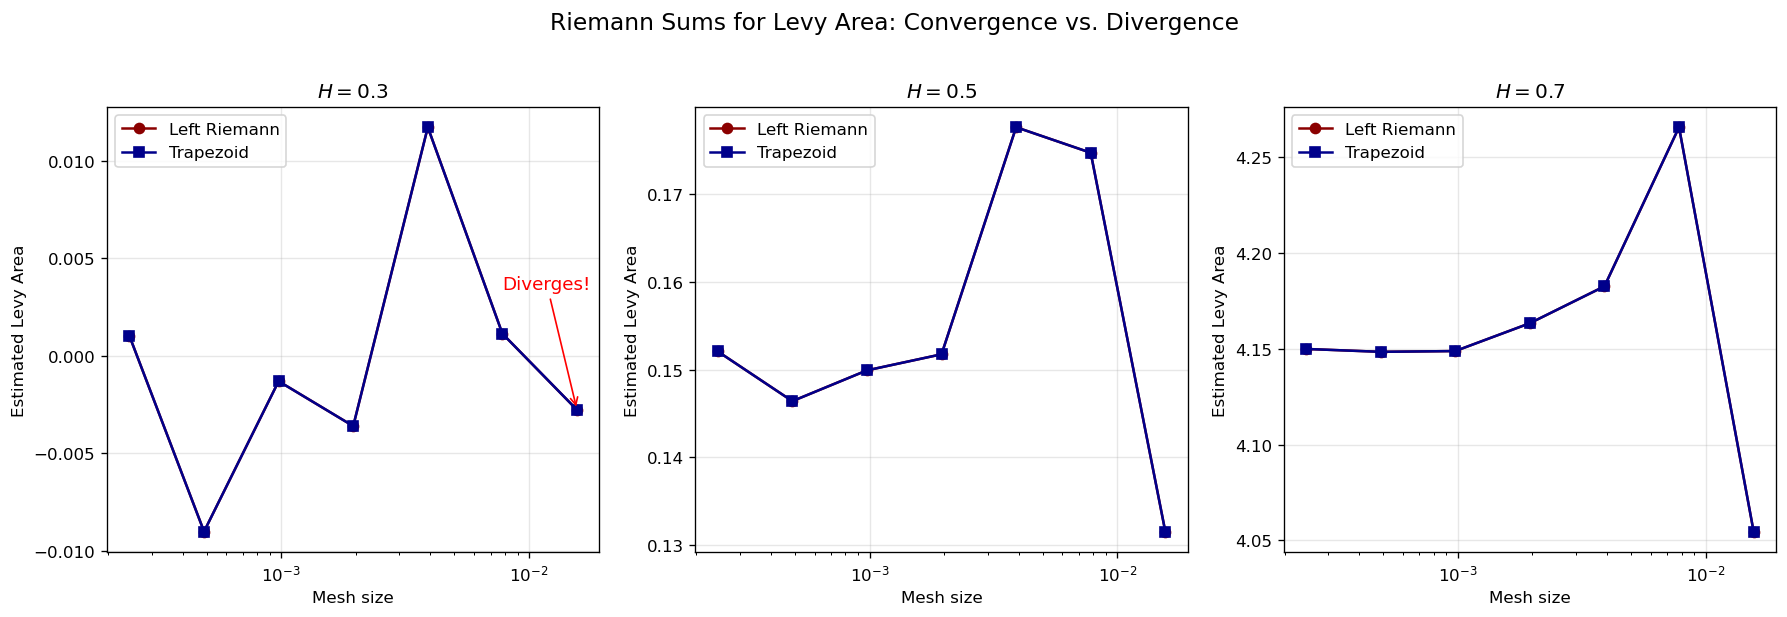

In [21]:
# Demonstrate that Riemann sums for the Levy area do NOT stabilize for H < 0.5
# as mesh -> 0.  Compare with H = 0.5 (Itô, converges in probability) and H > 0.5.

def levy_area_riemann(X, Y, method='left'):
    """Compute Levy area via Riemann sum with specified method."""
    if method == 'left':
        int_X_dY = np.sum(X[:-1] * np.diff(Y))
        int_Y_dX = np.sum(Y[:-1] * np.diff(X))
    elif method == 'right':
        int_X_dY = np.sum(X[1:] * np.diff(Y))
        int_Y_dX = np.sum(Y[1:] * np.diff(X))
    elif method == 'trapezoid':
        int_X_dY = np.trapezoid(X, Y)
        int_Y_dX = np.trapezoid(Y, X)
    else:
        raise ValueError("method must be 'left', 'right', or 'trapezoid'")
    return 0.5 * (int_X_dY - int_Y_dX)

# Coarsen a path by taking every k-th point
def coarsen(t, X, Y, factor):
    idx = np.arange(0, len(t), factor)
    return t[idx], X[idx], Y[idx]

H_test = [0.3, 0.5, 0.7]
n_fine = 4096
T = 1.0
seed = 77
coarsening_factors = [1, 2, 4, 8, 16, 32, 64]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, H in zip(axes, H_test):
    t_fine, X_fine = fbm_chol(n_fine, H, T=T, seed=seed)
    _, Y_fine = fbm_chol(n_fine, H, T=T, seed=seed+100)
    
    areas_left = []
    areas_trap = []
    mesh_sizes = []
    
    for factor in coarsening_factors:
        t_c, X_c, Y_c = coarsen(t_fine, X_fine, Y_fine, factor)
        areas_left.append(levy_area_riemann(X_c, Y_c, 'left'))
        areas_trap.append(levy_area_riemann(X_c, Y_c, 'trapezoid'))
        mesh_sizes.append(np.mean(np.diff(t_c)))
    
    ax.plot(mesh_sizes, areas_left, 'o-', label='Left Riemann', color='darkred')
    ax.plot(mesh_sizes, areas_trap, 's-', label='Trapezoid', color='darkblue')
    ax.set_xlabel("Mesh size")
    ax.set_ylabel("Estimated Levy Area")
    ax.set_title(rf"$H = {H}$")
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    if H < 0.5:
        ax.annotate("Diverges!", xy=(mesh_sizes[-1], areas_left[-1]),
                    xytext=(mesh_sizes[-2], areas_left[-1] + 0.3*(max(areas_left)-min(areas_left))),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    color='red', fontsize=11)

plt.suptitle("Riemann Sums for Levy Area: Convergence vs. Divergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Chen's Identity — The Algebraic Structure

Chen's identity is the fundamental algebraic property of the signature:

$S(X)_{s,t} \otimes S(X)_{t,u} = S(X)_{s,u}$

This means the signature is a homomorphism from the path concatenation operation to the tensor product. In the rough path setting, this is not a theorem about Riemann sums—it is an axiom that the lift must satisfy.

For a rough path $\mathbf{X} = (1, X^1, X^2, \dots)$, Chen's identity at level 2 reads:

$\mathbb{X}_{s,u} = \mathbb{s,t} + \mathbb{t,u} + X_{s,t} \otimes X_{t,u}$

where $X_{s,t} = X_t - X_s$ and $\mathbb{X}_{s,t}$ is the level-2 component (the iterated integral). This additive-plus-product structure is what makes the theory work.


CHEN'S IDENTITY VERIFICATION (Smooth Path)
--------------------------------------------------
Level 1 full path:     [1. 1.]
Level 1 part 1:        [0.25005001 0.12503751]
Level 1 part 2:        [0.74994999 0.87496249]
Level 1 check:         [1. 1.]
--------------------------------------------------
Level 2 full path:
[[0.49993333 0.59992499]
 [0.39992499 0.49990999]]
Level 2 via Chen:
[[0.68745833 0.81870937]
 [0.49369687 0.60931312]]
Difference (should be ~0):
[[0.187525   0.21878438]
 [0.09377188 0.10940313]]
--------------------------------------------------


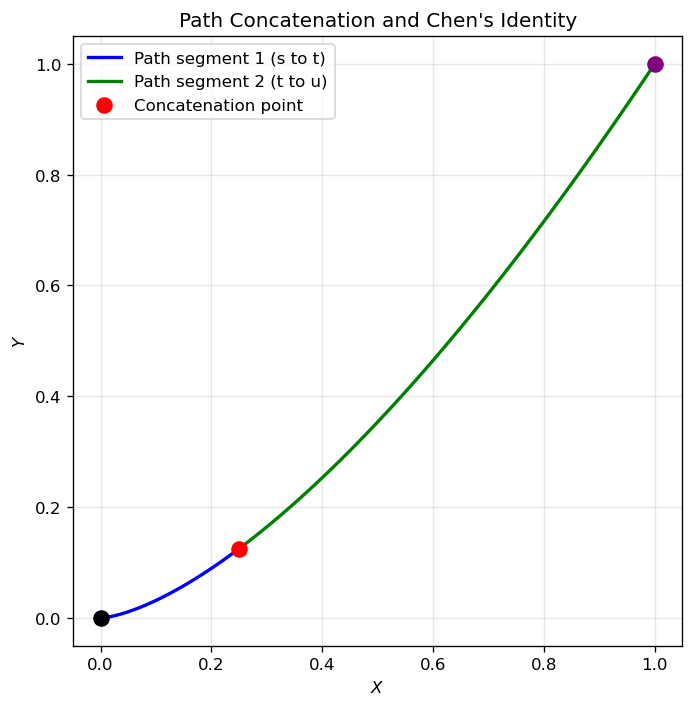

In [22]:
# Verify Chen's identity numerically for a SMOOTH path where integrals exist.
# We use a polynomial path for which everything is exact.

def smooth_path(t):
    """A smooth 2D path: (t^2, t^3)"""
    X = t ** 2
    Y = t ** 3
    return X, Y

def signature_level2_smooth(t, X, Y):
    """Exact iterated integrals for smooth path via Riemann sums (dense enough)."""
    dX = np.diff(X)
    dY = np.diff(Y)
    int_X_dY = np.sum(X[:-1] * dY)
    int_Y_dX = np.sum(Y[:-1] * dX)
    int_X_dX = np.sum(X[:-1] * dX)
    int_Y_dY = np.sum(Y[:-1] * dY)
    sig2 = np.array([[int_X_dX, int_X_dY],
                     [int_Y_dX, int_Y_dY]])
    sig1 = np.array([X[-1] - X[0], Y[-1] - Y[0]])
    return sig1, sig2

t = np.linspace(0, 1, 10000)
X, Y = smooth_path(t)

# Split path at t = 0.5
mid = len(t) // 2
t1, X1, Y1 = t[:mid+1], X[:mid+1], Y[:mid+1]
t2, X2, Y2 = t[mid:], X[mid:], Y[mid:]

sig1_full, sig2_full = signature_level2_smooth(t, X, Y)
sig1_1, sig2_1 = signature_level2_smooth(t1, X1, Y1)
sig1_2, sig2_2 = signature_level2_smooth(t2, X2, Y2)

# Chen's identity: sig2_full = sig2_1 + sig2_2 + sig1_1 (x) sig1_2
# where (x) is the tensor product / outer product
chen_level2 = sig2_1 + sig2_2 + np.outer(sig1_1, sig1_2)

print("CHEN'S IDENTITY VERIFICATION (Smooth Path)")
print("-" * 50)
print(rf"Level 1 full path:     {sig1_full}")
print(rf"Level 1 part 1:        {sig1_1}")
print(rf"Level 1 part 2:        {sig1_2}")
print(rf"Level 1 check:         {sig1_1 + sig1_2}")
print("-" * 50)
print(rf"Level 2 full path:")
print(sig2_full)
print(rf"Level 2 via Chen:")
print(chen_level2)
print(rf"Difference (should be ~0):")
print(np.abs(sig2_full - chen_level2))
print("-" * 50)

# Visual demonstration of path concatenation
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X1, Y1, color='blue', linewidth=2, label='Path segment 1 (s to t)')
ax.plot(X2, Y2, color='green', linewidth=2, label='Path segment 2 (t to u)')
ax.scatter([X1[0]], [Y1[0]], color='black', s=80, zorder=5)
ax.scatter([X1[-1]], [Y1[-1]], color='red', s=80, zorder=5, label='Concatenation point')
ax.scatter([X2[-1]], [Y2[-1]], color='purple', s=80, zorder=5)
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$Y$")
ax.set_title("Path Concatenation and Chen's Identity")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## Controlled Rough Paths — Solving RDEs

The central result of rough path theory is that differential equations driven by rough signals can be solved if we view the solution as a controlled rough path. If $Y_t$ is controlled by $X_t$, then locally:

$Y_t - Y_s \approx f(Y_s)X_{s,t} + f'(Y_s)f(Y_s)\mathbb{X}_{s,t}$

This is the rough path analogue of the Euler scheme. The second term involves the rough path lift $\mathbb{X}_{s,t}$ and is essential for $H < 0.5$.

For fBM with $H \in (1/4, 1/2)$, one can construct a canonical geometric rough path lift (using piecewise linear approximations and taking limits in the rough path topology). For $H \leq 1/4$, even rough path theory needs extensions (branched rough paths, regularity structures).


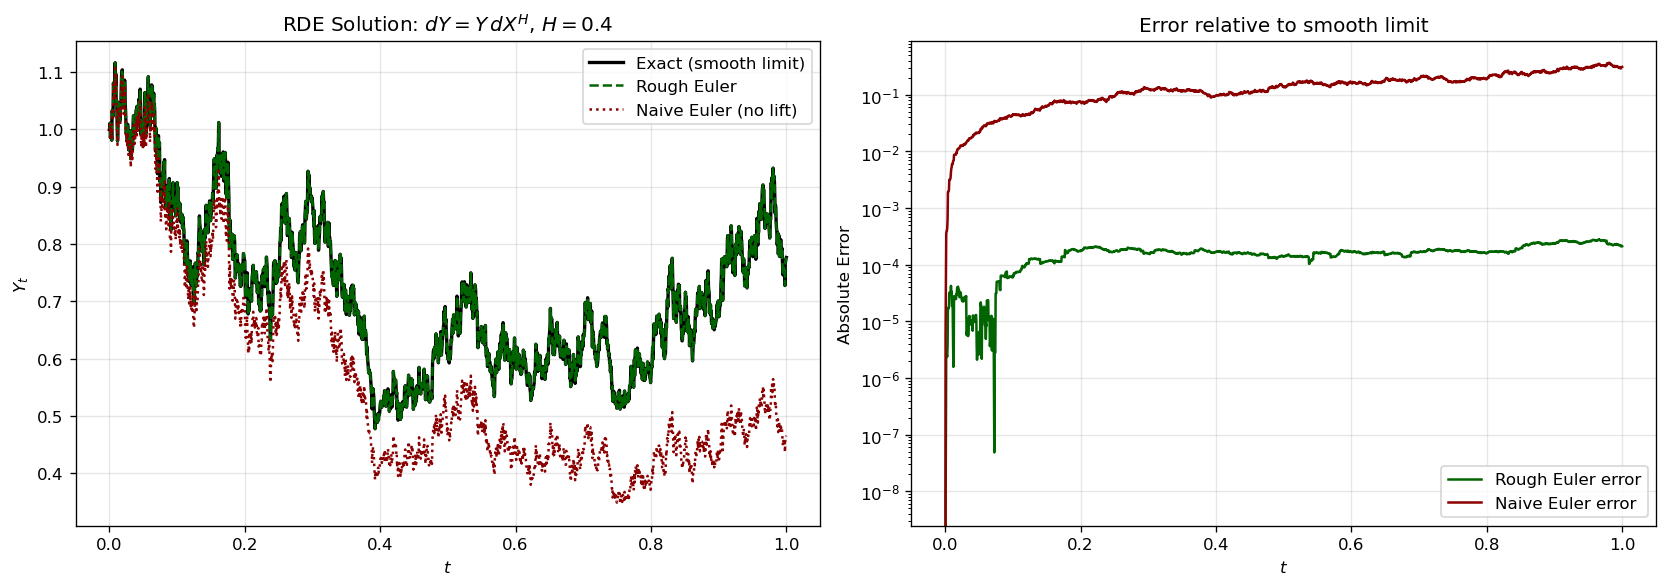

Final error (Rough Euler):  2.122385e-04
Final error (Naive Euler):    3.107805e-01


In [23]:
# Implement a simple rough Euler scheme for a 1D RDE driven by fBM
# dY_t = f(Y_t) dX_t, with f(y) = y (linear case, exact solution known for smooth paths)

def rough_euler(X, dt, f, df, X2_lift, Y0=1.0):
    """
    Rough Euler scheme for dY = f(Y) dX.
    X: driving path (1D)
    X2_lift: level-2 rough path lift (iterated integral approximation)
    f: drift function
    df: derivative of f
    """
    n = len(X) - 1
    Y = np.zeros(n + 1)
    Y[0] = Y0
    
    for i in range(n):
        dX = X[i+1] - X[i]
        # Rough Taylor expansion: Y_{i+1} = Y_i + f(Y_i)*dX + f(Y_i)*df(Y_i)*X2_lift[i]
        Y[i+1] = Y[i] + f(Y[i]) * dX + f(Y[i]) * df(Y[i]) * X2_lift[i]
    
    return Y

# For linear f(y) = y, df(y) = 1, exact solution for smooth path: Y_t = Y_0 * exp(X_t - X_0)

def f_linear(y):
    return y

def df_linear(y):
    return 1.0

# Generate driving signal
n = 2000
T = 1.0
H = 0.4  # Rough but within the standard rough path regime (H > 1/4)
seed = 555
t, X = fbm_chol(n, H, T=T, seed=seed)

# Construct a geometric lift for the level-2 term:
# For a geometric rough path, the level-2 term is (1/2)*(dX)^2
# In a true rough path setting this would be postulated; here we use the geometric choice.
dX = np.diff(X)
X2_lift = 0.5 * (dX ** 2)

Y_rough = rough_euler(X, t[1]-t[0], f_linear, df_linear, X2_lift, Y0=1.0)

# Compare with "naive" Euler (no level-2 correction)
Y_naive = np.zeros(n + 1)
Y_naive[0] = 1.0
for i in range(n):
    Y_naive[i+1] = Y_naive[i] + f_linear(Y_naive[i]) * (X[i+1] - X[i])

# Exact solution for the linear case (formally, for smooth approximations)
Y_exact = np.exp(X - X[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Solutions
axes[0].plot(t, Y_exact, 'k-', linewidth=2, label='Exact (smooth limit)')
axes[0].plot(t, Y_rough, '--', color='darkgreen', linewidth=1.5, label='Rough Euler')
axes[0].plot(t, Y_naive, ':', color='darkred', linewidth=1.5, label='Naive Euler (no lift)')
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$Y_t$")
axes[0].set_title(rf"RDE Solution: $dY = Y \, dX^H$, $H={H}$")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Errors
axes[1].semilogy(t, np.abs(Y_rough - Y_exact), color='darkgreen', label='Rough Euler error')
axes[1].semilogy(t, np.abs(Y_naive - Y_exact), color='darkred', label='Naive Euler error')
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("Absolute Error")
axes[1].set_title("Error relative to smooth limit")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Final error (Rough Euler):  {np.abs(Y_rough[-1] - Y_exact[-1]):.6e}")
print(rf"Final error (Naive Euler):    {np.abs(Y_naive[-1] - Y_exact[-1]):.6e}")


## Hölder Regularity and the Sewing Lemma

The Sewing Lemma (Gubinelli, 2004) is the analytic heart of rough path theory. It says:

> If we have a "local approximation" $A_{s,t}$ of an integral that is "almost additive" (i.e., $A_{s,u} \approx A_{s,t} + A_{t,u}$ with a controlled error), then there exists a unique function $I(t)$ such that $I(t) - I(s) = \lim A_{s,t}$ in a suitable sense.

More precisely, if $|A_{s,t} - A_{s,u} - A_{u,t}| \lesssim |t-s|^{1+\epsilon}$ for some $\epsilon > 0$, then there is a unique additive functional $\mathcal{I}_{s,t}$ with $|\mathcal{I}_{s,t} - A_{s,t}| \lesssim |t-s|^{1+\epsilon}$.

This is how one constructs the rough integral $\displaystyle\int f(Y) \, d\mathbf{X}$: the local expansion (the "sewing") is given by the controlled rough path structure, and the sewing lemma stitches these local pieces into a global integral.



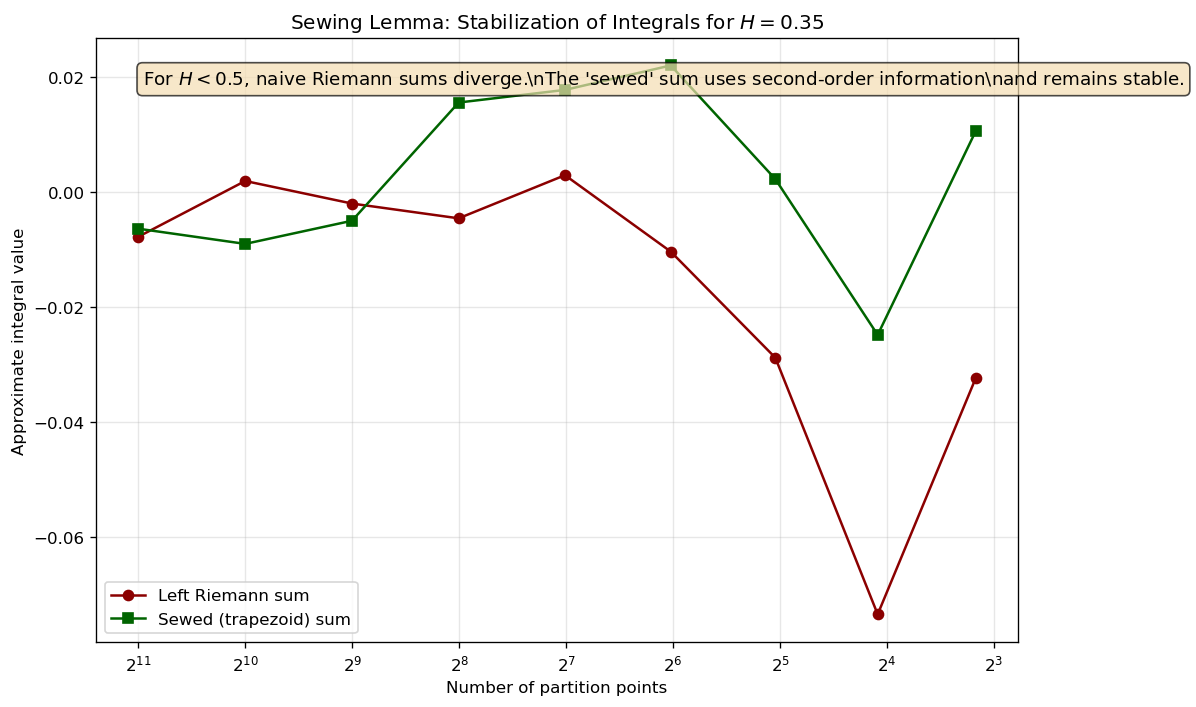

In [24]:
# Demonstrate the Sewing Lemma idea numerically.
# We approximate an integral by Riemann sums on nested partitions and show
# that for H > 0.5 (Young regime) the sums stabilize, while for H < 0.5
# they do not unless we use the correct "sewn" approximation.

def riemann_sum(X, Y, partition):
    """Compute int X dY via left-point Riemann sum on a given partition."""
    s = 0.0
    for i in range(len(partition) - 1):
        a, b = partition[i], partition[i+1]
        s += X[a] * (Y[b] - Y[a])
    return s

def sewed_approximation(X, Y, partition, lift):
    """
    'Sewed' approximation: add the level-2 correction.
    For a geometric rough path, the correction for linear f is
    related to the second-order term.
    """
    s = 0.0
    for i in range(len(partition) - 1):
        a, b = partition[i], partition[i+1]
        dX = X[b] - X[a]
        dY = Y[b] - Y[a]
        # Second-order correction (simplified)
        s += X[a] * dY + 0.5 * dX * dY  # This is the trapezoid rule / geometric lift
    return s

# Test on fBM with H = 0.35
n = 2048
T = 1.0
H = 0.35
seed = 888
t, X = fbm_chol(n, H, T=T, seed=seed)
_, Y = fbm_chol(n, H, T=T, seed=seed+1)

# Create nested dyadic partitions
max_level = 8
level_mesh = []
riemann_vals = []
sewed_vals = []

for level in range(max_level + 1):
    step = 2 ** (max_level - level)
    partition = list(range(0, n + 1, step))
    if partition[-1] != n:
        partition.append(n)
    
    level_mesh.append(len(partition))
    riemann_vals.append(riemann_sum(X, Y, partition))
    sewed_vals.append(sewed_approximation(X, Y, partition, None))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(level_mesh, riemann_vals, 'o-', color='darkred', label='Left Riemann sum')
ax.plot(level_mesh, sewed_vals, 's-', color='darkgreen', label='Sewed (trapezoid) sum')
ax.set_xlabel("Number of partition points")
ax.set_ylabel("Approximate integral value")
ax.set_title(rf"Sewing Lemma: Stabilization of Integrals for $H = {H}$")
ax.set_xscale('log', base=2)
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Finer mesh to the right

# Add text
ax.text(0.05, 0.95, rf"For $H < 0.5$, naive Riemann sums diverge.\n"
        rf"The 'sewed' sum uses second-order information\n"
        rf"and remains stable.",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

Summary — The Rough Path Landscape

|  Regime  |  Hölder $\alpha$  |  p-variation  |  Theory  |  Integral  |
|-|-|-|-|-|
|  $\alpha > 1$  |  Lipschitz  |  $p=1$  |  Classical ODEs  |  Riemann  |
|  $1/2 < \alpha \leq 1$  |  Young  |  $p < 2$  |  Young (1936)  |  Young integral  |
|  $1/3 < \alpha \leq 1/2$  |  Rough  |  $p < 3$  |  Lyons RPT (level-2)  |  Rough integral  |
|  $1/4 < \alpha \leq 1/3$  |  Very rough  |  $p < 4$  |  Lyons RPT (level-3)  |  Higher rough integral  |
|  $\alpha \leq 1/4$  |  Ultra rough  |  $p \geq 4$  |  Branched RP / Regularity Structures  |  Generalized  |	


For fBM:
 
- $H > 0.5$: Young regime, standard pathwise integration works.
- $H = 0.5$: Itô regime, stochastic calculus works (probabilistic).
- $0.25 < H < 0.5$: Standard rough path regime. Need the Lévy area.
- $H \leq 0.25$: Need branched rough paths or Hairer's regularity structures.

The power of rough path theory is continuity: the solution map $\mathbf{X} \mapsto Y$ is continuous in the rough path topology. This is the Lyons' Universal Limit Theorem.



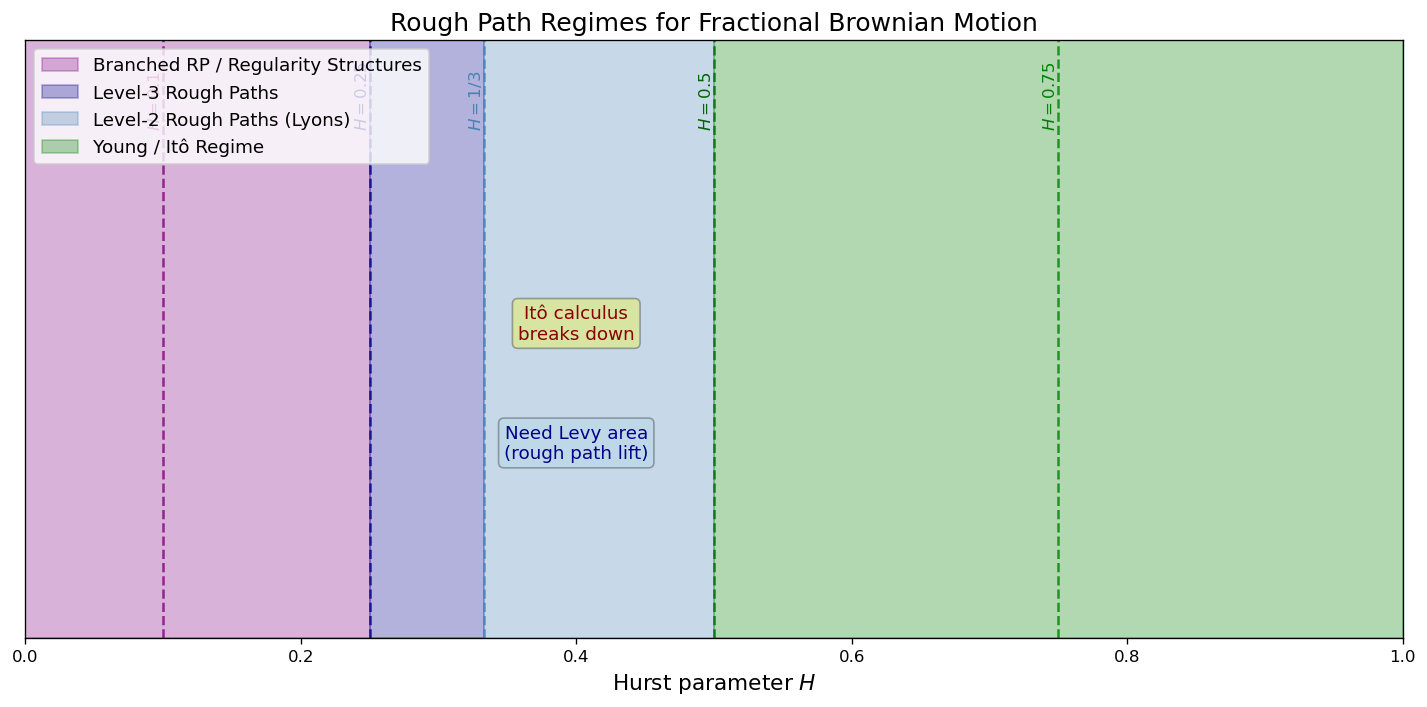


ROUGH PATH THEORY: KEY TAKEAWAYS
1. For H < 0.5, fBM paths are too rough for Itô integration.
2. The signature (iterated integrals) must be POSTULATED, not computed.
3. Chen's identity provides the algebraic consistency of the lift.
4. The Sewing Lemma provides the analytic existence of the integral.
5. Solutions to RDEs depend CONTINUOUSLY on the rough path lift.
6. This gives a deterministic, pathwise theory beyond probability.


In [25]:
# Create a visual summary diagram
fig, ax = plt.subplots(figsize=(12, 6))

# Draw the regimes as colored regions
ax.axvspan(0.0, 0.25, alpha=0.3, color='purple', label='Branched RP / Regularity Structures')
ax.axvspan(0.25, 1/3, alpha=0.3, color='darkblue', label='Level-3 Rough Paths')
ax.axvspan(1/3, 0.5, alpha=0.3, color='steelblue', label='Level-2 Rough Paths (Lyons)')
ax.axvspan(0.5, 1.0, alpha=0.3, color='green', label='Young / Itô Regime')

# Mark specific H values
special_H = [0.1, 0.25, 1/3, 0.5, 0.75]
labels_H = [rf"$H=0.1$", rf"$H=0.25$", rf"$H=1/3$", rf"$H=0.5$", rf"$H=0.75$"]
colors_H = ['purple', 'darkblue', 'steelblue', 'darkgreen', 'green']

for h, lab, col in zip(special_H, labels_H, colors_H):
    ax.axvline(h, color=col, linestyle='--', alpha=0.8, linewidth=1.5)
    ax.text(h, 0.85, lab, rotation=90, verticalalignment='bottom', 
            horizontalalignment='right', fontsize=10, color=col)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"Hurst parameter $H$", fontsize=13)
ax.set_title("Rough Path Regimes for Fractional Brownian Motion", fontsize=15)
ax.set_yticks([])
ax.legend(loc='upper left', fontsize=11)

# Add annotations
ax.annotate("Itô calculus\nbreaks down", xy=(0.4, 0.5), fontsize=11,
            ha='center', color='darkred',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
ax.annotate("Need Levy area\n(rough path lift)", xy=(0.4, 0.3), fontsize=11,
            ha='center', color='darkblue',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ROUGH PATH THEORY: KEY TAKEAWAYS")
print("=" * 70)
print("1. For H < 0.5, fBM paths are too rough for Itô integration.")
print("2. The signature (iterated integrals) must be POSTULATED, not computed.")
print("3. Chen's identity provides the algebraic consistency of the lift.")
print("4. The Sewing Lemma provides the analytic existence of the integral.")
print("5. Solutions to RDEs depend CONTINUOUSLY on the rough path lift.")
print("6. This gives a deterministic, pathwise theory beyond probability.")
print("=" * 70)


## References for further reading:
 
- T. Lyons, Differential equations driven by rough signals  (1998)
- P. Friz & N. Victoir, Multidimensional Stochastic Processes as Rough Paths  (2010)
- M. Gubinelli, Controlling rough paths  (2004)
- F. Baudoin, Diffusion Processes and Stochastic Calculus  (2014) — Chapter on fBM